In [1]:
import sys
sys.path.append('../')

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from helpers.cm26 import DatasetCM26, read_datasets
from helpers.selectors import *
from helpers.operators import Coarsen, Filtering, Subsampling, CoarsenKochkov, CoarsenWeighted, CoarsenKochkovMinMax
from helpers.state_functions import *

#import hvplot.xarray
import hvplot
import cmocean

%load_ext autoreload
%autoreload 3

# Screening models for offline analysis

In [14]:
def read_skill(exp='subfilter/FGR3/EXP1', factors=[4,9,12,15], base_path='/scratch/pp2681/mom6/CM26_ML_models/ocean3d/'):
    ds = {}
    for factor in factors:
        data = xr.open_dataset(f'{base_path}/{exp}/skill-test/factor-{factor}.nc', chunks={'zl':1})
        data['zl'] = -data['zl']

        try:
            # Compute RMSE and MSE metrics
            mask = xr.where(data.RMSE_map == 0., np.nan, 1.)
            
            data['MSE'] = (data.RMSE_map.astype('float64')**2 * mask).mean(['xh', 'yh']).compute()
            data['RMSE'] = np.sqrt(data['MSE'])
    
            data['MSET'] = (data.RMSET_map.astype('float64')**2 * mask).mean(['xh', 'yh']).compute()
            data['RMSET'] = np.sqrt(data['MSET'])
        except:
            pass
        
        ds[factor] = data
        
    return ds

In [15]:
import cmocean
def plot_metric(exp=None, metric='R2',vmin=0,vmax=1,cmap=cmocean.cm.balance,err_format="%.2f", show_numbers=True):
    data = xr.concat([exp[factor][metric] for factor in [4,9,12,15]], dim='factor')
    data.drop_vars(['zl']).plot(x='factor', y='zl',cmap=cmap, vmin=vmin, vmax=vmax, cbar_kwargs={'label':''})

    if show_numbers:
    # Add text annotations
        for i in range(data.shape[0]):
            for j in range(data.shape[1]):
                plt.text(i, j, '%.2f' % float(data[i,j]),
                        ha='center', va='center', color='white', fontsize=10)
    
    plt.yticks(np.arange(10),[5, 55, 110, 180,330, 730,1500,2500,3500,4500]);
    plt.ylabel('Depth, m')
    plt.xticks(np.arange(4),[4,9,12,15]);
    if metric == 'R2':
        title_str = '$R^2$'
    elif metric == 'corr':
        title_str = 'Correlation'
    elif metric == 'opt_scaling':
        title_str = 'Optimal scaling'
    
    mean_val = float(data.mean())
    min_val = float(data.min())
    max_val = float(data.max())
    plt.title(metric+f' = ${err_format}$ $({err_format}-{err_format})$' % (mean_val,min_val,max_val), fontsize=12)
    
    plt.xlabel('Coarsegraining factor')
    plt.gca().invert_yaxis()

# Fit ZB20 using the same strategy as ANNs

## One-parameter fitting procedure

Now we minimize the MSE error which is:
$$
L = \sum_{factor, zl, t}  \left[ \left( ||\mathrm{ZB20u} \cdot \alpha -  \mathrm{SGSx}||_2^2 + ||\mathrm{ZB20v} \cdot \alpha -  \mathrm{SGSy}||_2^2 \right) / \left(||\mathrm{SGSx}||_2^2 + ||\mathrm{SGSy}||_2^2 \right) \right]
$$
Optimum should satisfy:
$$
\partial_\alpha L = \sum_{factor, zl, t} \left[ \left( \left(\mathrm{ZB20u} \cdot \alpha -  \mathrm{SGSx}, \mathrm{ZB20u} \right) + \left(\mathrm{ZB20v} \cdot \alpha -  \mathrm{SGSy}, \mathrm{ZB20v} \right) \right) / \left(||\mathrm{SGSx}||_2^2 + ||\mathrm{SGSy}||_2^2 \right) \right] = 0
$$
i.e.
$$
\alpha  \sum_{f,z,t} \frac{(ZB,ZB)}{(SGS,SGS)} = \sum_{f,z,t} \frac{(SGS,ZB)}{(SGS,SGS)}
$$

In [39]:
ds = read_datasets(['train'], [4,9,12,15])

Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter/FGR3/factor-4
Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter/FGR3/factor-9
Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter/FGR3/factor-12
Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter/FGR3/factor-15


In [9]:
def scal_prod_2D(fx,fy,gx,gy):
    return (fx * gx).sum(['xq','yh']) + (fy * gy).sum(['xh','yq'])

In [10]:
from helpers.cm26 import propagate_mask
def fit_one_parameter(ds, factors=[9], depth=slice(0,1), **kw_ZB):
    numerator = 0
    denominator = 0

    for factor in factors:
        wet2_u = propagate_mask(ds[f'train-{factor}'].param.wet_u, ds[f'train-{factor}'].grid, niter=2)
        wet2_v = propagate_mask(ds[f'train-{factor}'].param.wet_v, ds[f'train-{factor}'].grid, niter=2)

        ZB20 = ds[f'train-{factor}'].state.ZB20(**kw_ZB)
        ZB20u = (wet2_u*ZB20['ZB20u']).isel(zl=depth).astype('float64')
        ZB20v = (wet2_v*ZB20['ZB20v']).isel(zl=depth).astype('float64')
        SGSx = (wet2_u*ds[f'train-{factor}'].data.SGSx).isel(zl=depth).astype('float64')
        SGSy = (wet2_v*ds[f'train-{factor}'].data.SGSy).isel(zl=depth).astype('float64')

        numerator += ((scal_prod_2D(ZB20u, ZB20v, SGSx, SGSy) / scal_prod_2D(SGSx, SGSy, SGSx, SGSy)).sum(['time', 'zl'])).compute()
        denominator += ((scal_prod_2D(ZB20u, ZB20v, ZB20u, ZB20v) / scal_prod_2D(SGSx, SGSy, SGSx, SGSy)).sum(['time', 'zl'])).compute()
    
    return float(numerator / denominator)

In [16]:
from dask.diagnostics import ProgressBar
with ProgressBar():
    %time alpha_compute = fit_one_parameter(ds)

[########################################] | 100% Completed | 3.88 sms
[########################################] | 100% Completed | 3.90 sms
CPU times: user 17.8 s, sys: 841 ms, total: 18.6 s
Wall time: 14.2 s


In [17]:
# Test value is 0.777
alpha_compute

0.7773671790799543

In [18]:
with ProgressBar():
    %time alpha_compute = fit_one_parameter(ds, factors=[4,9,12,15], depth=slice(None,None))

[########################################] | 100% Completed | 50.37 s
[########################################] | 100% Completed | 48.45 s
[########################################] | 100% Completed | 40.55 s
[########################################] | 100% Completed | 39.78 s
[########################################] | 100% Completed | 39.53 s
[########################################] | 100% Completed | 39.19 s
[########################################] | 100% Completed | 37.29 s
[########################################] | 100% Completed | 38.51 s
CPU times: user 12min 59s, sys: 1min 5s, total: 14min 4s
Wall time: 7min 7s


In [19]:
# ZB_scaling estimated on all data
alpha_compute

0.6518637036862618

# Fit VGM2 on all data

In [21]:
with ProgressBar():
    %time alpha_compute = fit_one_parameter(ds, factors=[4,9,12,15], depth=slice(None,None), VGM='direct', FGR=3, ZB_scaling=1, higher_order=True, subtract_div=False)

[########################################] | 100% Completed | 73.95 s
[########################################] | 100% Completed | 66.76 s
[########################################] | 100% Completed | 56.72 s
[########################################] | 100% Completed | 56.36 s
[########################################] | 100% Completed | 53.01 s
[########################################] | 100% Completed | 55.12 s
[########################################] | 100% Completed | 52.34 s
[########################################] | 100% Completed | 54.21 s
CPU times: user 18min 49s, sys: 1min 39s, total: 20min 29s
Wall time: 10min 25s


In [22]:
# VGM2 scaling estimated on all data
alpha_compute

2.0207277164004633

# Fit two parameters of VGM2

$$
L = \sum_{factor, zl, t}  \left[ \left( ||\alpha x_1 + \beta x_2 -  x||_2^2 + ||\alpha y_1 + \beta y_2 -  y||_2^2 \right) / \left(||x||_2^2 + ||y||_2^2 \right) \right]
$$

Let's for simplisity introduce normalized vectors:
$$
l = \sqrt{||x||_2^2 + ||y||_2}
$$
$$
x = x / l
$$
and so on

Then:
$$
L = \sum_{f,z,t}  ||\alpha x_1 + \beta x_2 -  x||_2^2 + ||\alpha y_1 + \beta y_2 -  y||_2^2
$$

Then
$$
\partial_\alpha L = \sum_{f,z,t} (\alpha x_1 + \beta x_2 -  x, x_1) + (\alpha y_1 + \beta y_2 -  y, y_1) = 0
$$
and
$$
\partial_\beta L = \sum_{f,z,t} (\alpha x_1 + \beta x_2 -  x, x_2) + (\alpha y_1 + \beta y_2 -  y, y_2) = 0
$$
Final system:
$$
\alpha \sum_{f,z,t} \left( (x_1,x_1) + (y_1,y_1) \right) + \beta \sum_{f,z,t} \left( (x_2,x_1) + (y_2,y_1) \right) = \sum_{f,z,t} \left( (x,x_1) + (y,y_1) \right)
$$
$$
\alpha \sum_{f,z,t} \left( (x_1, x_2) + (y_1,y_2) \right) + \beta \sum_{f,z,t} \left( (x_2, x_2) + (y_2, y_2) \right) = \sum_{f,z,t} \left( (x,x_2) + (y,y_2) \right)
$$
In short:
$$
\begin{pmatrix}
A & B \\
B & C
\end{pmatrix} \cdot \begin{pmatrix}
\alpha \\
\beta
\end{pmatrix} = 
\begin{pmatrix}
a \\
b
\end{pmatrix}
$$

In [45]:
def fit_two_parameter(ds, factors=[9], depth=slice(0,1), **kw_ZB):
    A = 0
    B = 0
    C = 0
    a = 0
    b = 0
    for factor in factors:
        wet2_u = propagate_mask(ds[f'train-{factor}'].param.wet_u, ds[f'train-{factor}'].grid, niter=2)
        wet2_v = propagate_mask(ds[f'train-{factor}'].param.wet_v, ds[f'train-{factor}'].grid, niter=2)

        ZB20 = ds[f'train-{factor}'].state.ZB20(**kw_ZB)
        SGSx = (wet2_u*ds[f'train-{factor}'].data.SGSx).isel(zl=depth).astype('float64')
        SGSy = (wet2_v*ds[f'train-{factor}'].data.SGSy).isel(zl=depth).astype('float64')

        SGS_norm = np.sqrt((SGSx**2).sum(['xq', 'yh']) + (SGSy**2).sum(['xh', 'yq']))

        x = SGSx / SGS_norm
        y = SGSy / SGS_norm

        x1 = (wet2_u * ZB20['ZB20u_l']).isel(zl=depth).astype('float64')
        x2 = (wet2_u * ZB20['ZB20u_h']).isel(zl=depth).astype('float64')

        y1 = (wet2_v * ZB20['ZB20v_l']).isel(zl=depth).astype('float64')
        y2 = (wet2_v * ZB20['ZB20v_h']).isel(zl=depth).astype('float64')

        x1 = x1 / SGS_norm
        x2 = x2 / SGS_norm

        y1 = y1 / SGS_norm
        y2 = y2 / SGS_norm

        A += scal_prod_2D(x1,y1,x1,y1).sum(['zl','time'])
        B += scal_prod_2D(x1,y1,x2,y2).sum(['zl','time'])
        C += scal_prod_2D(x2,y2,x2,y2).sum(['zl','time'])

        a += scal_prod_2D(x,y,x1,y1).sum(['zl','time'])
        b += scal_prod_2D(x,y,x2,y2).sum(['zl','time'])

    A = float(A)
    B = float(B)
    C = float(C)

    a = float(a)
    b = float(b)

    M = np.array([
        [A, B],
        [B,C]])
    two_parameters = np.linalg.inv(M) @ np.array([a,b])
    
    return two_parameters

## First, make sure that two-parameter procedure is more accurate than one-parameter for the same data

In [40]:
# Test new function for fitting
with ProgressBar():
    %time alpha_compute = fit_one_parameter(ds, factors=[9], depth=slice(0,1), VGM='direct', FGR=3, ZB_scaling=1, higher_order=True, subtract_div=False)

print(alpha_compute)

[########################################] | 100% Completed | 7.33 ss
[########################################] | 100% Completed | 5.54 sms
CPU times: user 32.8 s, sys: 1.53 s, total: 34.3 s
Wall time: 27.7 s
2.5569036977189286


In [46]:
# Test new function for fitting
with ProgressBar():
    %time two_parameter = fit_two_parameter(ds, factors=[9], depth=slice(0,1), VGM='direct', FGR=3, ZB_scaling=1, higher_order=True, subtract_div=False)

print(two_parameter)

[########################################] | 100% Completed | 3.48 sms
[########################################] | 100% Completed | 6.65 ss
[########################################] | 100% Completed | 5.03 sms
[########################################] | 100% Completed | 3.57 sms
[########################################] | 100% Completed | 5.05 sms
CPU times: user 53.9 s, sys: 2.74 s, total: 56.7 s
Wall time: 44.6 s
[2.10128131 3.75151623]


In [48]:
dataset = ds['train-9'].select2d(time=0,zl=0)

In [49]:
VGM2 = dataset.state.ZB20(VGM='direct', FGR=3, ZB_scaling=1, higher_order=True, subtract_div=False)
VGM2_fit = dataset.state.ZB20(VGM='direct', FGR=3, ZB_scaling=2.5569036977189286, higher_order=True, subtract_div=False)
VGM2_fit2 = dataset.state.ZB20(VGM='direct', FGR=3, two_parameters=[2.10128131, 3.75151623],  higher_order=True, subtract_div=False)

Correlation: 0.7333398024811844
Relative Error: 0.8305536271192385
R2 =  0.3414683040329122
R2 max =  0.5377891774731147
Optinal scaling: 2.526497453959058
Nans [test/control]: [57920, 57920]


array([[<Axes: title={'center': 'Tested field'}, xlabel='ucell longitude [degrees_E]', ylabel='yh'>,
        <Axes: title={'center': 'Control field'}, xlabel='xq', ylabel='yh'>],
       [<Axes: title={'center': 'Tested field $-$ Control field'}, xlabel='ucell longitude [degrees_E]', ylabel='yh'>,
        <Axes: >]], dtype=object)

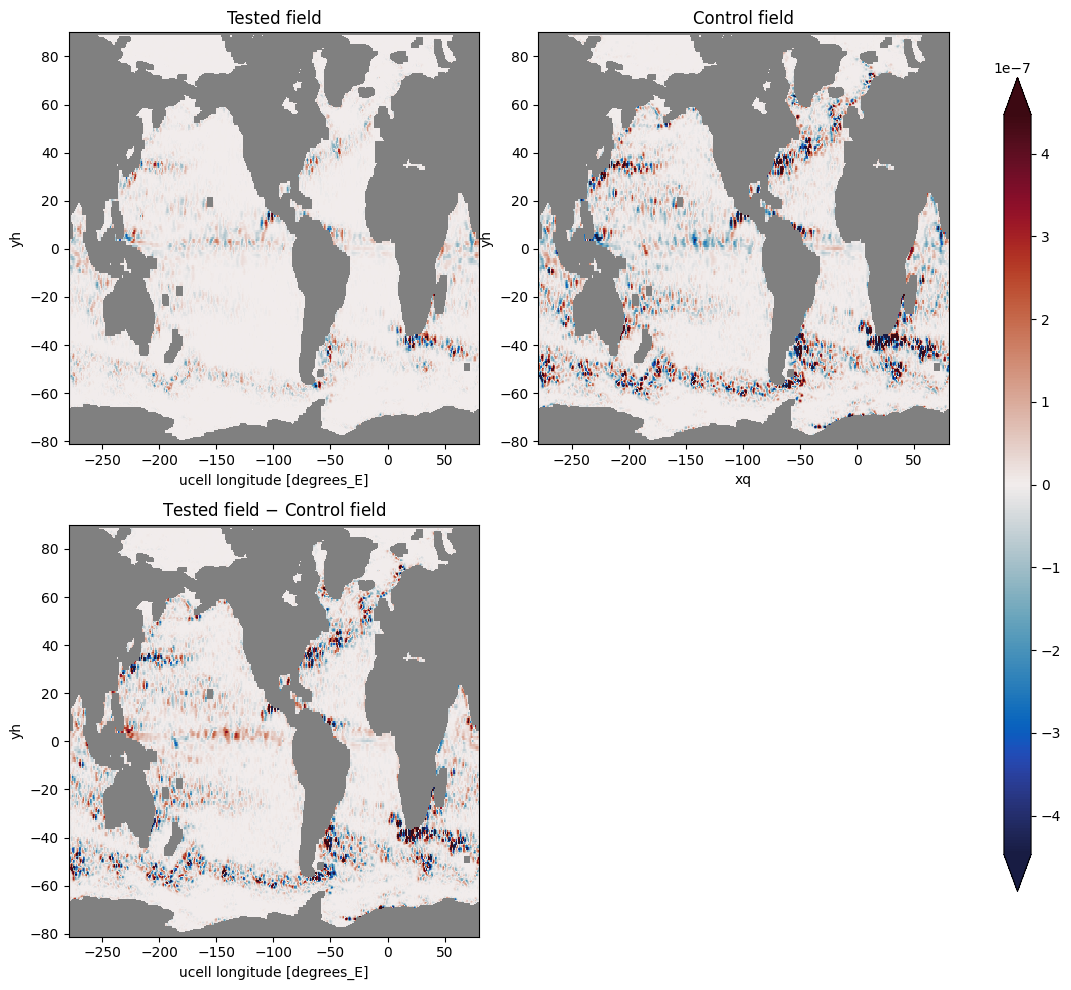

In [52]:
compare(dataset.nanvar(VGM2['ZB20u'],2), dataset.nanvar(dataset.data.SGSx,2), selector=select_globe)

Correlation: 0.7333398024811844
Relative Error: 0.7491186052688913
R2 =  0.5377112842177252
R2 max =  0.5377891774731146
Optinal scaling: 0.9881081779548457
Nans [test/control]: [57920, 57920]


array([[<Axes: title={'center': 'Tested field'}, xlabel='ucell longitude [degrees_E]', ylabel='yh'>,
        <Axes: title={'center': 'Control field'}, xlabel='xq', ylabel='yh'>],
       [<Axes: title={'center': 'Tested field $-$ Control field'}, xlabel='ucell longitude [degrees_E]', ylabel='yh'>,
        <Axes: >]], dtype=object)

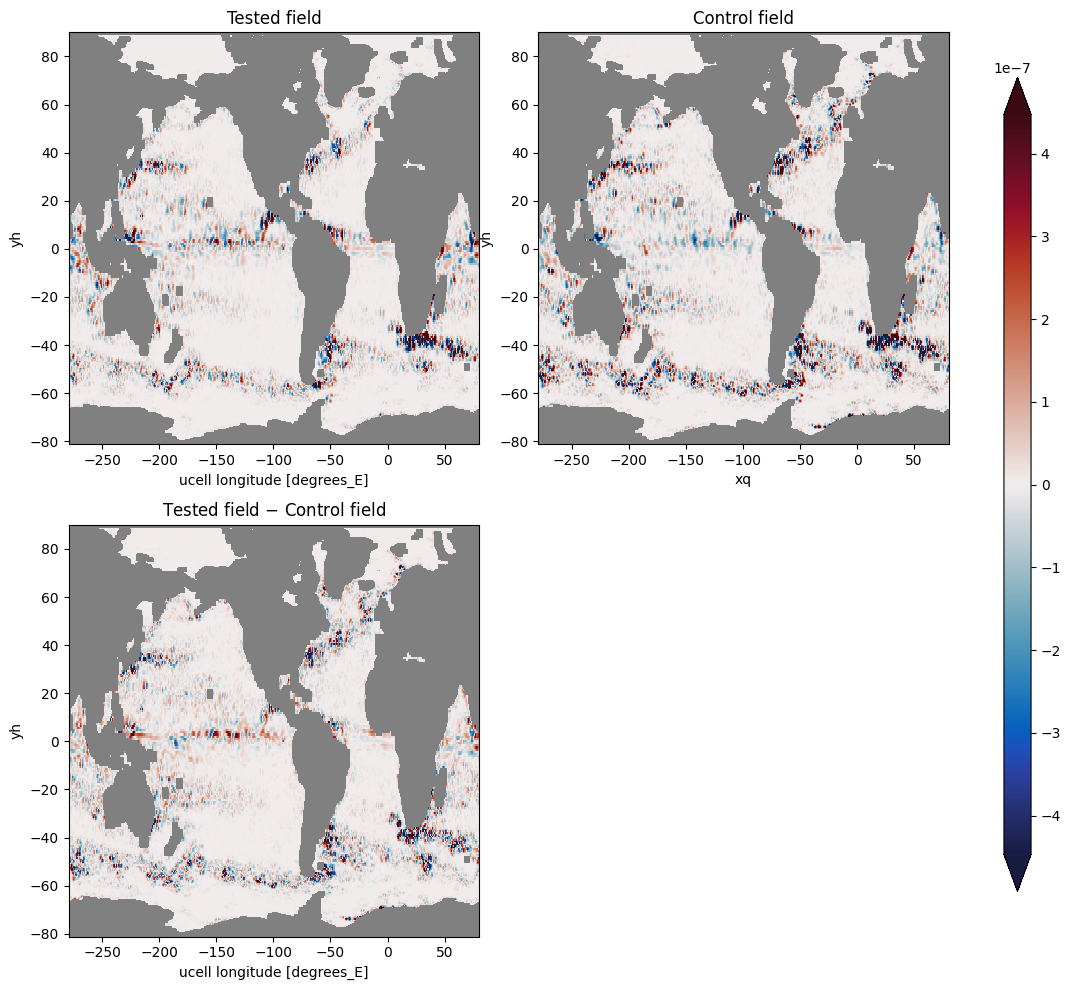

In [53]:
compare(dataset.nanvar(VGM2_fit['ZB20u'],2), dataset.nanvar(dataset.data.SGSx,2), selector=select_globe)

Correlation: 0.7681653176067433
Relative Error: 0.7069533493357892
R2 =  0.5900013315950507
R2 max =  0.5900796637839094
Optinal scaling: 0.9886095827836716
Nans [test/control]: [57920, 57920]


array([[<Axes: title={'center': 'Tested field'}, xlabel='ucell longitude [degrees_E]', ylabel='yh'>,
        <Axes: title={'center': 'Control field'}, xlabel='xq', ylabel='yh'>],
       [<Axes: title={'center': 'Tested field $-$ Control field'}, xlabel='ucell longitude [degrees_E]', ylabel='yh'>,
        <Axes: >]], dtype=object)

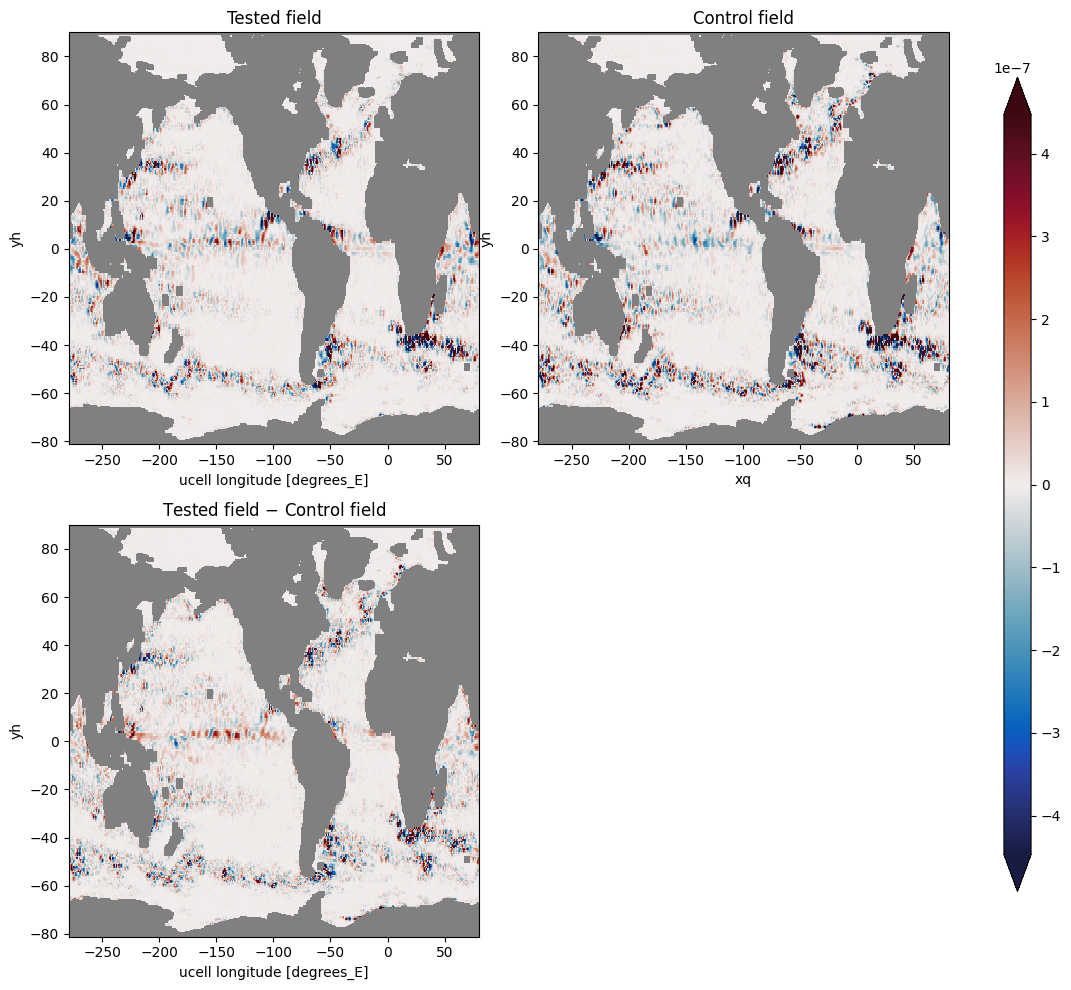

In [54]:
compare(dataset.nanvar(VGM2_fit2['ZB20u'],2), dataset.nanvar(dataset.data.SGSx,2), selector=select_globe)

# Now we fit to the full dataset

In [55]:
# Test new function for fitting
with ProgressBar():
    %time two_parameter = fit_two_parameter(ds, factors=[4,9,12,15], depth=slice(None,None), VGM='direct', FGR=3, ZB_scaling=1, higher_order=True, subtract_div=False)

print(two_parameter)

[########################################] | 100% Completed | 154.10 s
[########################################] | 100% Completed | 298.66 s
[###########################             ] | 68% Completed | 168.72 s

IOStream.flush timed out


[########################################] | 100% Completed | 226.77 s
[########################################] | 100% Completed | 160.36 s
[########################################] | 100% Completed | 229.56 s
CPU times: user 39min 8s, sys: 3min 43s, total: 42min 51s
Wall time: 22min 30s
[1.61059287 3.39681279]


# Now we make a prediction with optimal parameters

In [4]:
ds = read_datasets(['test'], [4,9,12,15], subfilter='subfilter-large', FGR=3)

Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter-large/FGR3/factor-4
Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter-large/FGR3/factor-9
Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter-large/FGR3/factor-12
Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter-large/FGR3/factor-15


In [5]:
path_save = '/scratch/pp2681/mom6/CM26_ML_models/ocean3d/subfilter-large/FGR3/ZB20/fit-all-data'
import os
os.system(f'mkdir -p {path_save}/skill-test')

In [8]:
import gc
for factor in [4, 9,12,15]:
    %time skill = ds[f'test-{factor}'].predict_ZB(ZB_scaling = 0.6518637036862618).SGS_skill()
    skill.to_netcdf(f'{path_save}/skill-test/factor-{factor}.nc')
    del skill
    gc.collect()
    print(f'Testing on dataset with factor {factor} is complete')

CPU times: user 7min 1s, sys: 2min 11s, total: 9min 12s
Wall time: 6min 58s
Testing on dataset with factor 4 is complete
CPU times: user 1min 39s, sys: 23.7 s, total: 2min 3s
Wall time: 1min 46s
Testing on dataset with factor 9 is complete
CPU times: user 1min 9s, sys: 13.8 s, total: 1min 23s
Wall time: 1min 14s
Testing on dataset with factor 12 is complete
CPU times: user 54.7 s, sys: 8.16 s, total: 1min 2s
Wall time: 58.8 s
Testing on dataset with factor 15 is complete


In [9]:
path_save = '/scratch/pp2681/mom6/CM26_ML_models/ocean3d/subfilter-large/FGR3/VGM2/fit-all-data'
import os
os.system(f'mkdir -p {path_save}/skill-test')

0

In [10]:
import gc
for factor in [4, 9,12,15]:
    %time skill = ds[f'test-{factor}'].predict_ZB(VGM='direct', FGR=3, ZB_scaling=2.0207277164004633, higher_order=True, subtract_div=False).SGS_skill()
    skill.to_netcdf(f'{path_save}/skill-test/factor-{factor}.nc')
    del skill
    gc.collect()
    print(f'Testing on dataset with factor {factor} is complete')

CPU times: user 8min 10s, sys: 2min 9s, total: 10min 20s
Wall time: 7min 10s
Testing on dataset with factor 4 is complete
CPU times: user 1min 57s, sys: 23.8 s, total: 2min 21s
Wall time: 1min 54s
Testing on dataset with factor 9 is complete
CPU times: user 1min 23s, sys: 13.7 s, total: 1min 37s
Wall time: 1min 22s
Testing on dataset with factor 12 is complete
CPU times: user 1min 6s, sys: 8.92 s, total: 1min 15s
Wall time: 1min 7s
Testing on dataset with factor 15 is complete


In [11]:
path_save = '/scratch/pp2681/mom6/CM26_ML_models/ocean3d/subfilter-large/FGR3/VGM2/fit2-all-data'
import os
os.system(f'mkdir -p {path_save}/skill-test')

0

In [13]:
import gc
for factor in [4, 9,12,15]:
    %time skill = ds[f'test-{factor}'].predict_ZB(VGM='direct', FGR=3, two_parameters=[1.61059287, 3.39681279], higher_order=True, subtract_div=False).SGS_skill()
    skill.to_netcdf(f'{path_save}/skill-test/factor-{factor}.nc')
    del skill
    gc.collect()
    print(f'Testing on dataset with factor {factor} is complete')

CPU times: user 8min 13s, sys: 2min 9s, total: 10min 23s
Wall time: 7min 13s
Testing on dataset with factor 4 is complete
CPU times: user 2min, sys: 24.1 s, total: 2min 24s
Wall time: 1min 57s
Testing on dataset with factor 9 is complete
CPU times: user 1min 24s, sys: 13.7 s, total: 1min 38s
Wall time: 1min 24s
Testing on dataset with factor 12 is complete
CPU times: user 1min 9s, sys: 8.23 s, total: 1min 17s
Wall time: 1min 9s
Testing on dataset with factor 15 is complete


# Compare fitted VGM2 versus ANN

In [16]:
data = {}
for key in ['default']:
    data[key] = read_skill(f'subfilter-large/FGR3/dimensional-scaling/20/{key}');

In [45]:
baselines = {}
baselines['ZB20-fit'] = read_skill(f'subfilter-large/FGR3/ZB20/fit-all-data');
baselines['VGM2-no-fit'] = read_skill(f'subfilter-large/FGR3/VGM2/no-fit');
baselines['VGM2-fit-1'] = read_skill(f'subfilter-large/FGR3/VGM2/fit-all-data');
baselines['VGM2-fit-2'] = read_skill(f'subfilter-large/FGR3/VGM2/fit2-all-data');
baselines['ann1x1'] = read_skill(f'subfilter/FGR3/features_stencil/stencil-1-no-radius');

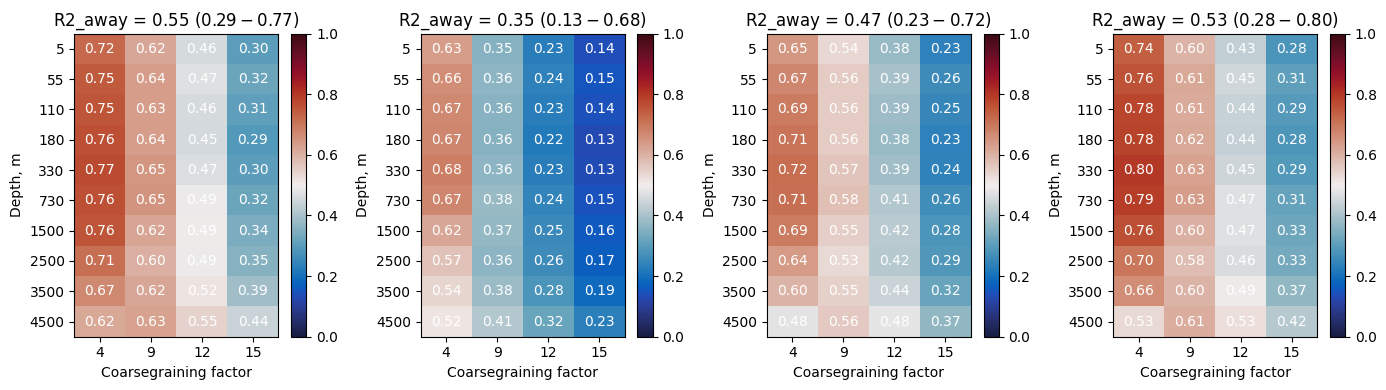

In [19]:
# Neural network versus baselines

plt.figure(figsize=(14,4))
plt.subplot(1,4,1)
plot_metric(data['default'], 'R2_away', vmin=0)
plt.subplot(1,4,2)
plot_metric(baselines['VGM2-no-fit'],'R2_away', vmin=0)
plt.subplot(1,4,3)
plot_metric(baselines['VGM2-fit-1'],'R2_away', vmin=0)
plt.subplot(1,4,4)
plot_metric(baselines['VGM2-fit-2'],'R2_away', vmin=0)

plt.tight_layout()

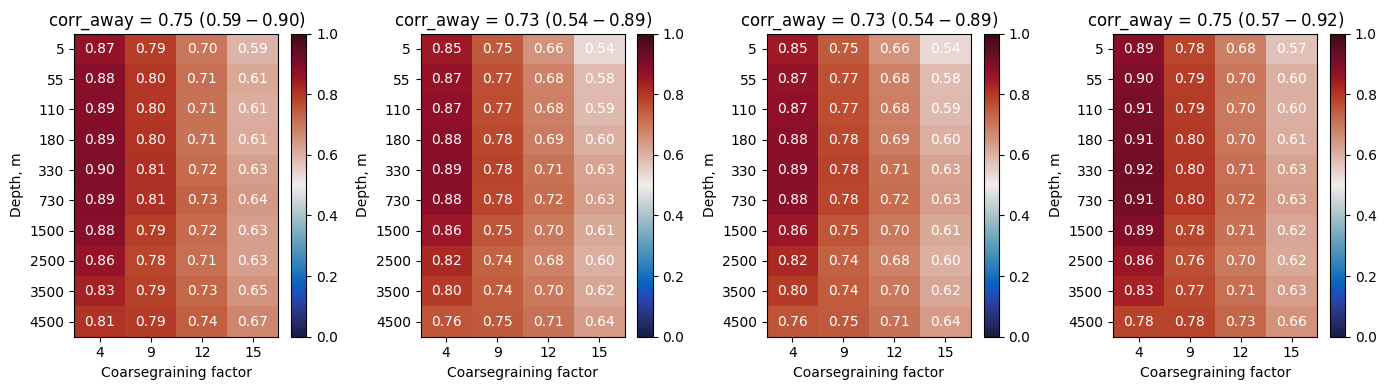

In [40]:
# Neural network versus baselines

plt.figure(figsize=(14,4))
plt.subplot(1,4,1)
plot_metric(data['default'], 'corr_away', vmin=0)
plt.subplot(1,4,2)
plot_metric(baselines['VGM2-no-fit'],'corr_away', vmin=0)
plt.subplot(1,4,3)
plot_metric(baselines['VGM2-fit-1'],'corr_away', vmin=0)
plt.subplot(1,4,4)
plot_metric(baselines['VGM2-fit-2'],'corr_away', vmin=0)

plt.tight_layout()

In [46]:
def plot_spectra(region = 'NA', factor = 4, zl = 0):
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    data['default'][factor][f'power_ZB_{region}'].mean('time').isel(zl=zl).plot(label='ANN', lw=2)

    baselines['VGM2-no-fit'][factor][f'power_ZB_{region}'].mean('time').isel(zl=zl).plot(label='VGM2 no fit', lw=2)
    baselines['VGM2-fit-1'][factor][f'power_ZB_{region}'].mean('time').isel(zl=zl).plot(label='VGM2 fit 1 parameter', lw=2)
    baselines['VGM2-fit-2'][factor][f'power_ZB_{region}'].mean('time').isel(zl=zl).plot(label='VGM2 fit 2 parameters', lw=2, color='tab:cyan', ls='--')
    baselines['ZB20-fit'][factor][f'power_ZB_{region}'].mean('time').isel(zl=zl).plot(label='ZB20 fit', lw=2)

    data['default'][factor][f'power_{region}'].mean('time').isel(zl=zl).plot(color='k', label='Truth')

    plt.xscale('log'); plt.yscale('log')
    
    plt.legend()
    plt.title('Power spectrum')
    
    plt.subplot(1,2,2)
    data['default'][factor][f'transfer_ZB_{region}'].mean('time').isel(zl=zl).plot(label='ANN', lw=2)

    baselines['VGM2-no-fit'][factor][f'transfer_ZB_{region}'].mean('time').isel(zl=zl).plot(label='VGM2 no fit', lw=2)
    baselines['VGM2-fit-1'][factor][f'transfer_ZB_{region}'].mean('time').isel(zl=zl).plot(label='VGM2 fit 1 parameter', lw=2)
    baselines['VGM2-fit-2'][factor][f'transfer_ZB_{region}'].mean('time').isel(zl=zl).plot(label='VGM2 fit 2 parameters', lw=2, color='tab:cyan', ls='--')
    baselines['ZB20-fit'][factor][f'transfer_ZB_{region}'].mean('time').isel(zl=zl).plot(label='ZB20 fit', lw=2)

    data['default'][factor][f'transfer_{region}'].mean('time').isel(zl=zl).plot(color='k', label='Truth')
    
    plt.xscale('log');
    plt.title('Energy transfer spectrum')
    depth =  - data['default'][factor].zl[zl]
    plt.suptitle(f'Coarsegraining factor = {factor}, depth = {int(depth)}, region={region}', y=1.1)

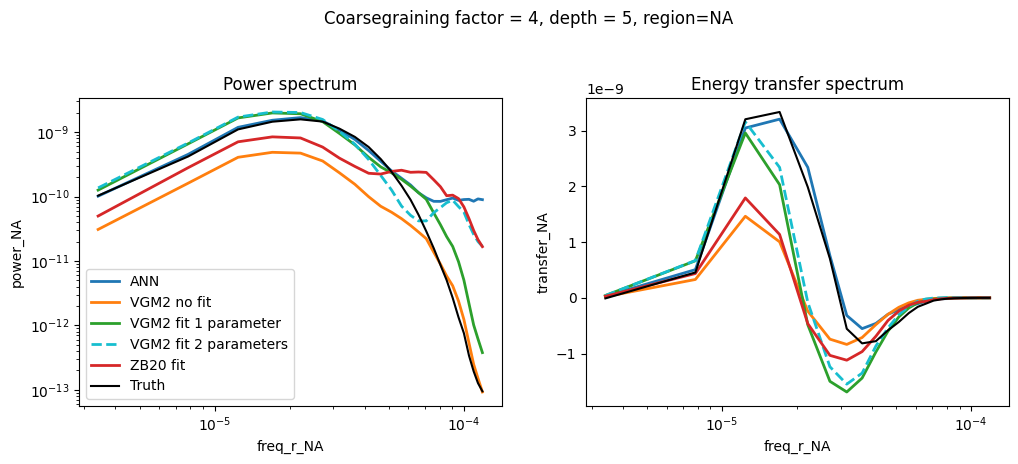

In [47]:
plot_spectra()

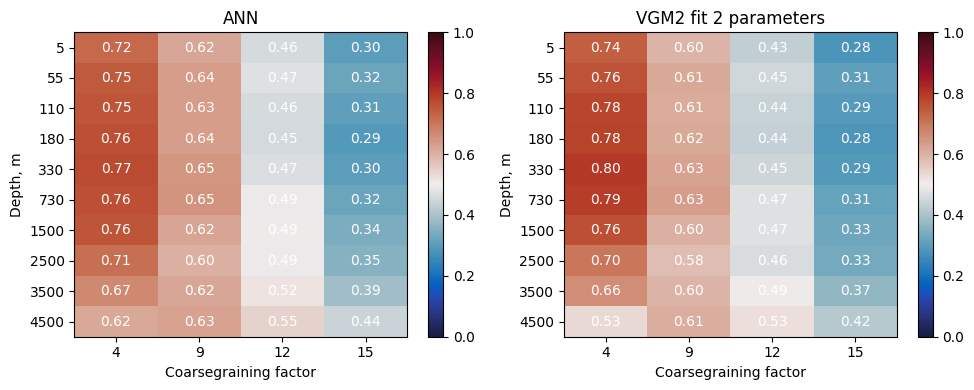

In [44]:
# Neural network versus baselines

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plot_metric(data['default'], 'R2_away', vmin=0)
plt.title('ANN')
plt.subplot(1,2,2)
plot_metric(baselines['VGM2-fit-2'],'R2_away', vmin=0)
plt.title('VGM2 fit 2 parameters')

plt.tight_layout()

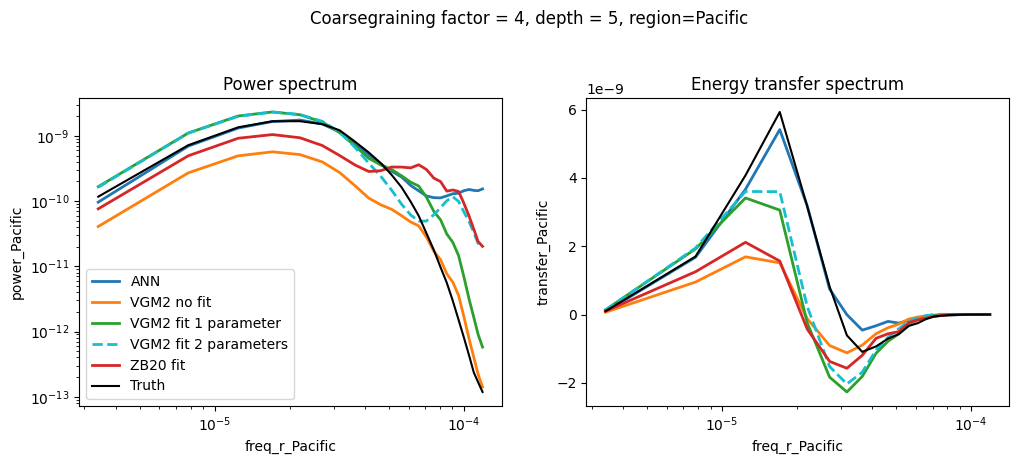

In [48]:
plot_spectra(region='Pacific')

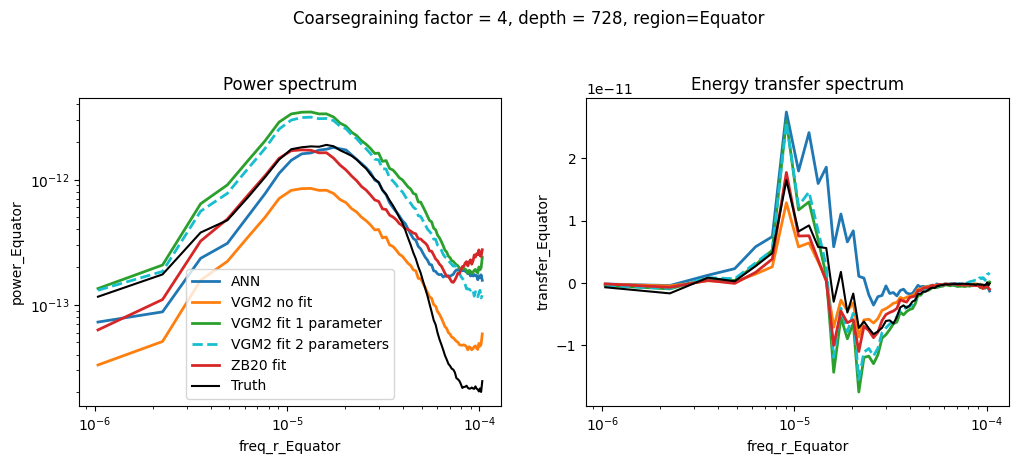

In [49]:
plot_spectra(region='Equator', zl=5)

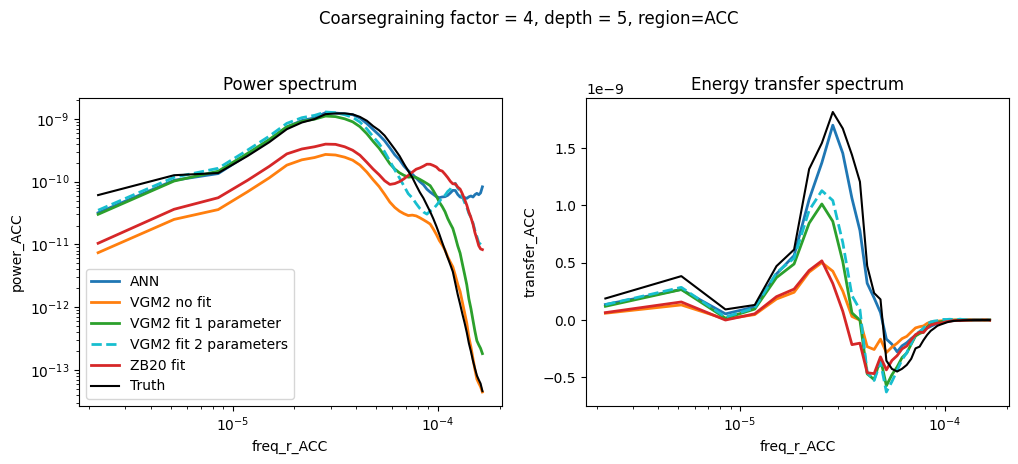

In [50]:
plot_spectra(region='ACC', zl=0)

Correlation: 0.8964373593077202
Relative Error: 0.5192785618850826
R2 =  0.7997526639088701
R2 max =  0.8040160289635971
Optinal scaling: 1.0785380073901452
Nans [test/control]: [0, 0]


array([[<Axes: title={'center': 'Tested field'}, xlabel='xh', ylabel='yh'>,
        <Axes: title={'center': 'Control field'}, xlabel='xh', ylabel='yh'>],
       [<Axes: title={'center': 'Tested field $-$ Control field'}, xlabel='xh', ylabel='yh'>,
        <Axes: >]], dtype=object)

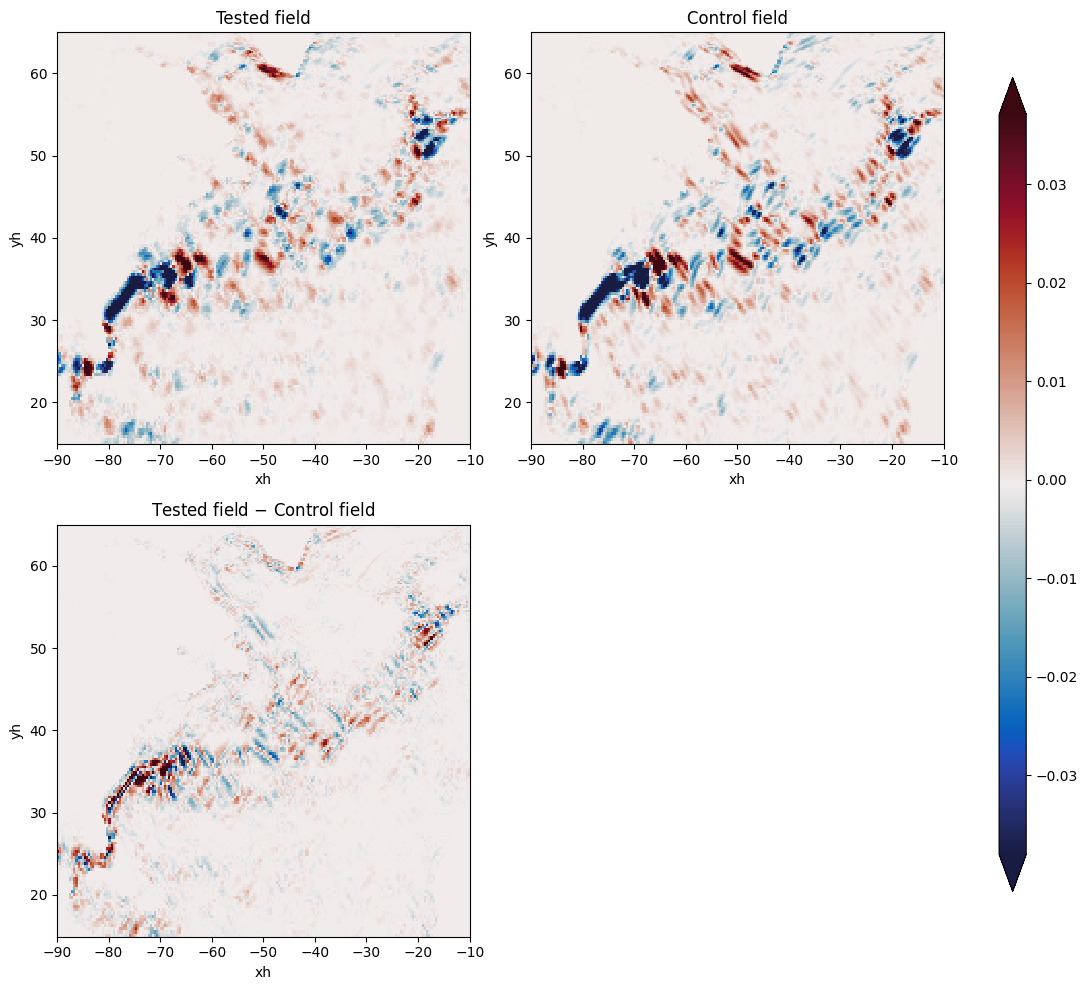

In [58]:
compare(data['default'][4].Txy_pred.isel(zl=0),baselines['VGM2-fit-1'][4].Txy_pred.isel(zl=0))

Correlation: 0.9269678014336525
Relative Error: 0.5535286192316834
R2 =  0.8097470940369267
R2 max =  0.8598127989008828
Optinal scaling: 0.8056030331062712
Nans [test/control]: [0, 0]


array([[<Axes: title={'center': 'Tested field'}, xlabel='xh', ylabel='yh'>,
        <Axes: title={'center': 'Control field'}, xlabel='xh', ylabel='yh'>],
       [<Axes: title={'center': 'Tested field $-$ Control field'}, xlabel='xh', ylabel='yh'>,
        <Axes: >]], dtype=object)

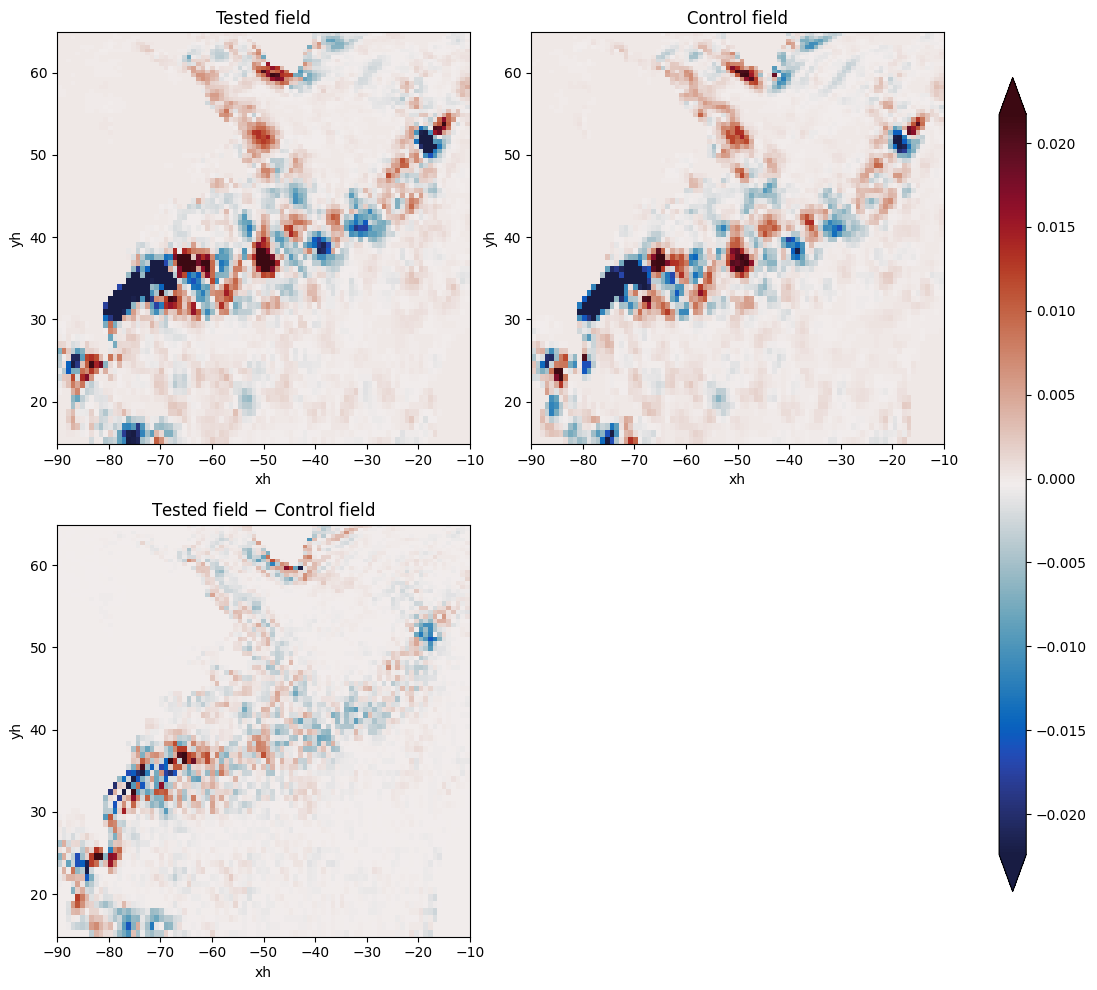

In [59]:
compare(data['default'][9].Txy_pred.isel(zl=0),baselines['VGM2-fit-1'][9].Txy_pred.isel(zl=0))

Correlation: 0.9353645040387389
Relative Error: 0.44170058879917584
R2 =  0.869406843941644
R2 max =  0.8751557151393645
Optinal scaling: 1.0881976175760464
Nans [test/control]: [0, 0]


array([[<Axes: title={'center': 'Tested field'}, xlabel='xh', ylabel='yh'>,
        <Axes: title={'center': 'Control field'}, xlabel='xh', ylabel='yh'>],
       [<Axes: title={'center': 'Tested field $-$ Control field'}, xlabel='xh', ylabel='yh'>,
        <Axes: >]], dtype=object)

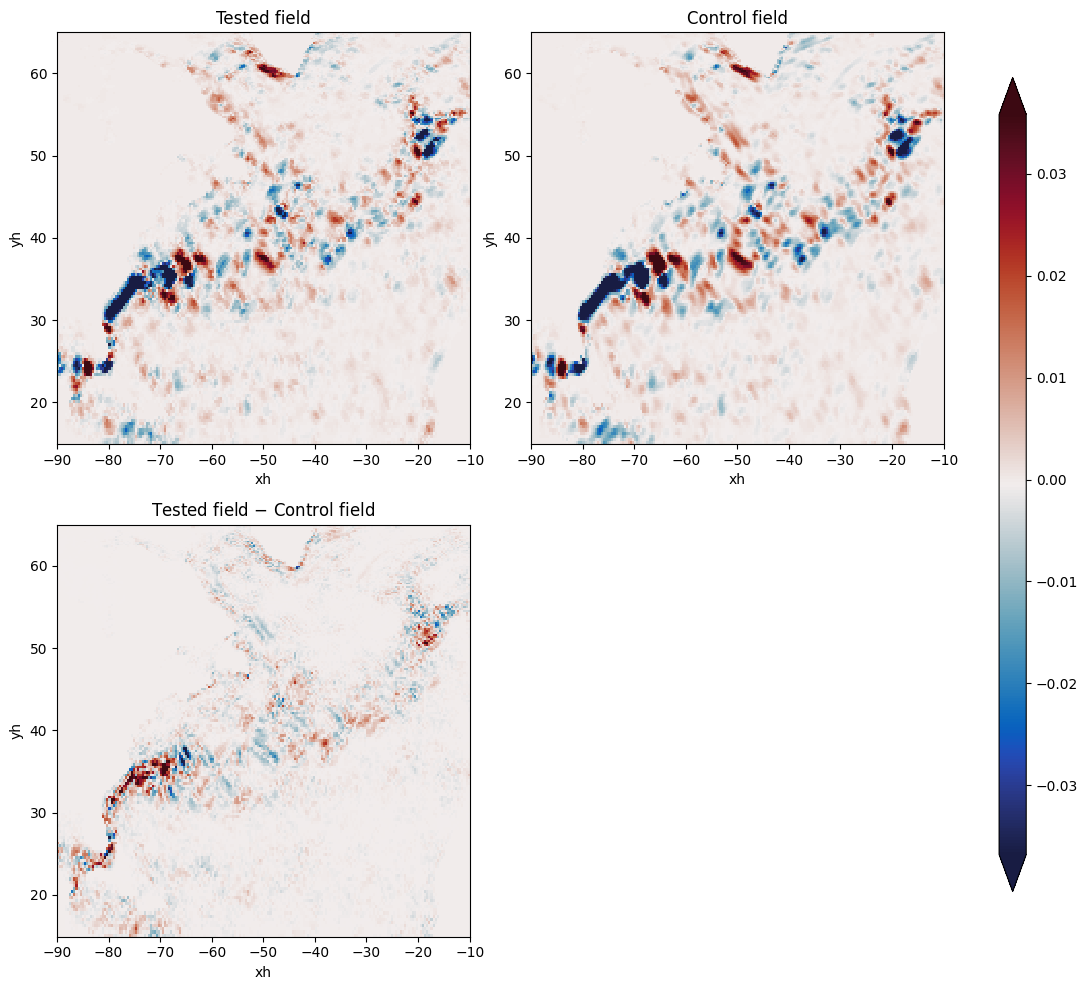

In [61]:
compare(data['default'][4].Txy_pred.isel(zl=0),baselines['VGM2-fit-2'][4].Txy_pred.isel(zl=0))